# Legal NLP Model Evaluation: Qwen vs. Claude Ground Truth
This notebook evaluates the performance of the Qwen extraction model against ground truth data (Claude). It calculates Exact Match Accuracy, Token F1 Scores, ROUGE Scores, and BERTScore for various legal document fields.

In [1]:
# Install required libraries (uncomment if running for the first time)
# !pip install pandas rouge-score bert-score scikit-learn matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from rouge_score import rouge_scorer
from bert_score import score
import warnings

warnings.filterwarnings('ignore')

# Set a beautiful, professional theme for all visualizations
sns.set_theme(style="whitegrid")
custom_palette = sns.color_palette("husl", 8)

/mnt/Data/yashv7523/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/mnt/Data/yashv7523/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


## 1. Data Loading & Preprocessing
Loading the ground truth and prediction datasets, standardizing column names, and merging them on `case_id`.

In [2]:
# Load Datasets
claude = pd.read_excel("enriched_legal_records.xlsx")
qwen = pd.read_excel("indilex_extracted_output_Qwen.xlsx")

# Standardize Claude columns to match Qwen
claude = claude.rename(columns={
    "CASE ID": "case_id",
    "LANGUAGE": "language",
    "CASE TYPE": "case_type",
    "JUDGMENT TEXT": "judgment_text",
    "SUBJECT": "subject",
    "OBJECT": "object",
    "OBJECTIVE ASPECT": "objective_aspect",
    "SUBJECTIVE ASPECT": "subjective_aspect",
    "LEGAL PROVISIONS": "legal_provisions",
    "REASONING": "reasoning"
})

# Merge datasets
df = pd.merge(claude, qwen, on="case_id", suffixes=("_gt", "_pred"))
print(f"Merged Dataset Shape: {df.shape}")

Merged Dataset Shape: (4, 23)


## 2. Exact Match Evaluation
Calculating how often the model's extraction perfectly matches the ground truth (case insensitive and stripped of whitespace).

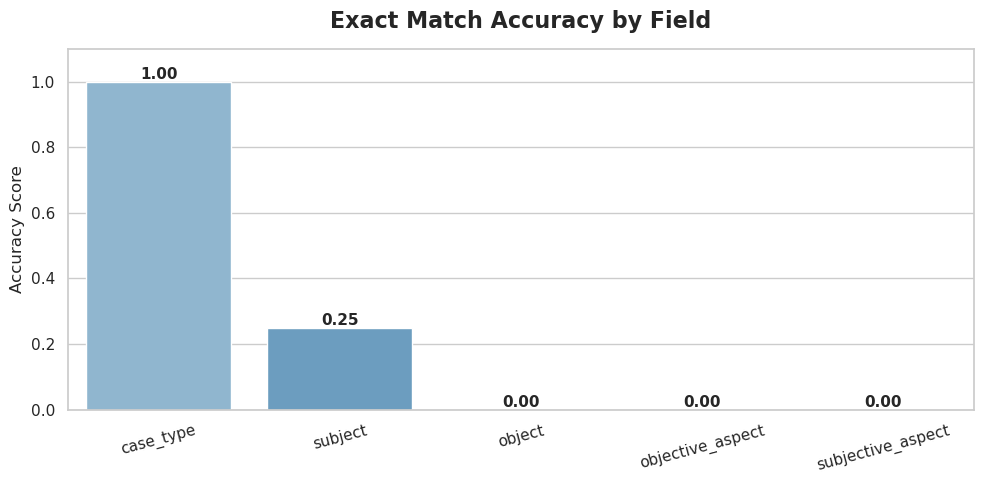

In [3]:
fields_em = ["case_type", "subject", "object", "objective_aspect", "subjective_aspect"]
em_scores = {}

for field in fields_em:
    acc = (
        df[f"{field}_gt"].astype(str).str.lower().str.strip() 
        == 
        df[f"{field}_pred"].astype(str).str.lower().str.strip()
    ).mean()
    em_scores[field] = acc

# --- Visualization ---
plt.figure(figsize=(10, 5))
ax = sns.barplot(x=list(em_scores.keys()), y=list(em_scores.values()), palette="Blues_d")
plt.title("Exact Match Accuracy by Field", fontsize=16, fontweight='bold', pad=15)
plt.ylabel("Accuracy Score", fontsize=12)
plt.ylim(0, 1.1)

# Add value labels on top of bars
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 3. Token F1 Score Evaluation
Exact match is often too strict. Token F1 measures the overlap of individual words between the prediction and ground truth.

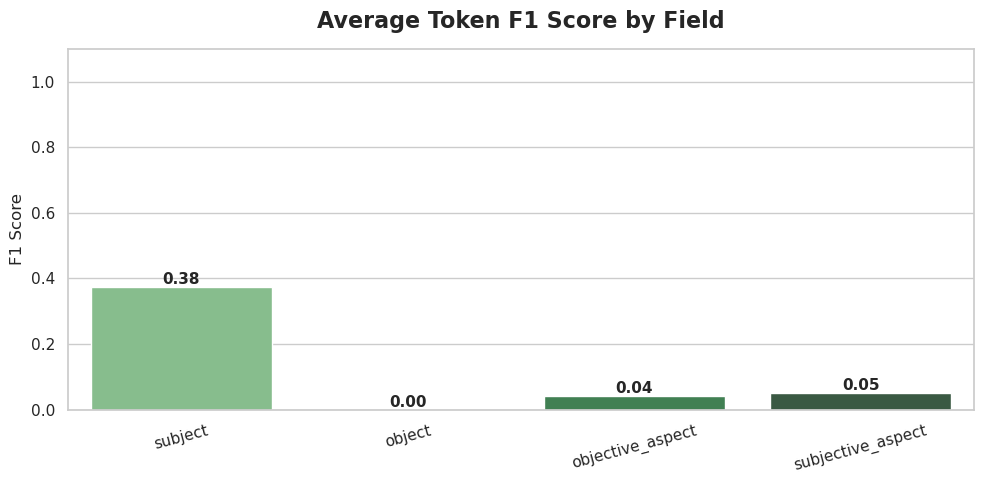

In [4]:
def token_f1(gt, pred):
    gt_tokens = set(str(gt).lower().split())
    pred_tokens = set(str(pred).lower().split())
    
    tp = len(gt_tokens.intersection(pred_tokens))
    precision = tp / max(len(pred_tokens), 1)
    recall = tp / max(len(gt_tokens), 1)
    
    if precision + recall == 0:
        return 0
    return (2 * precision * recall) / (precision + recall)

fields_f1 = ["subject", "object", "objective_aspect", "subjective_aspect"]
f1_scores = {}

for field in fields_f1:
    scores = [token_f1(row[f"{field}_gt"], row[f"{field}_pred"]) for _, row in df.iterrows()]
    f1_scores[field] = np.mean(scores)

# --- Visualization ---
plt.figure(figsize=(10, 5))
ax = sns.barplot(x=list(f1_scores.keys()), y=list(f1_scores.values()), palette="Greens_d")
plt.title("Average Token F1 Score by Field", fontsize=16, fontweight='bold', pad=15)
plt.ylabel("F1 Score", fontsize=12)
plt.ylim(0, 1.1)

for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 4. NLP Generation Metrics (Reasoning)
Evaluating the long-form "reasoning" field using ROUGE (n-gram overlap) and BERTScore (semantic similarity).

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


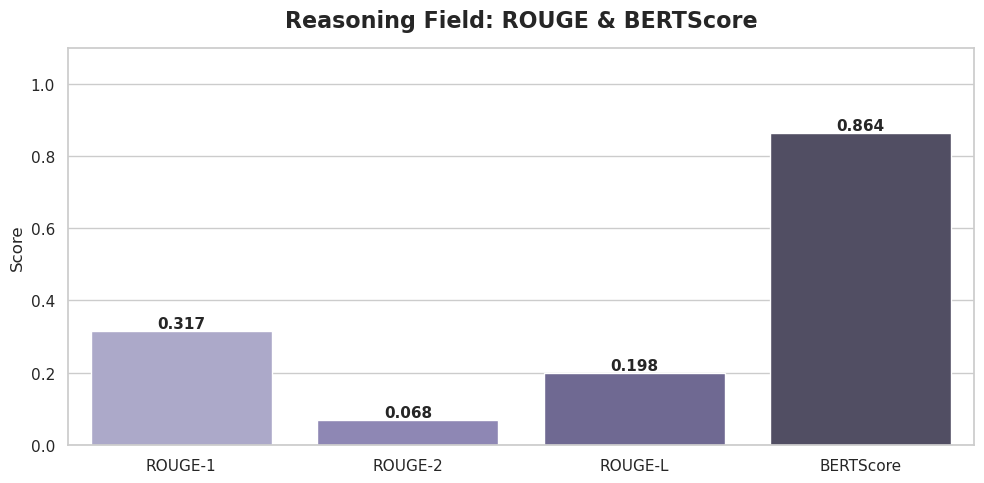

In [5]:
# 1. ROUGE Scores
scorer = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)
r1, r2, rl = [], [], []

for _, row in df.iterrows():
    score_dict = scorer.score(str(row["reasoning_gt"]), str(row["reasoning_pred"]))
    r1.append(score_dict["rouge1"].fmeasure)
    r2.append(score_dict["rouge2"].fmeasure)
    rl.append(score_dict["rougeL"].fmeasure)

rouge_results = {
    "ROUGE-1": np.mean(r1),
    "ROUGE-2": np.mean(r2),
    "ROUGE-L": np.mean(rl)
}

# 2. BERTScore
predictions = df["reasoning_pred"].astype(str).tolist()
references = df["reasoning_gt"].astype(str).tolist()

P, R, F1 = score(predictions, references, lang="en", verbose=False)
bert_score_val = F1.mean().item()

# Combine metrics for visualization
generation_metrics = {**rouge_results, "BERTScore": bert_score_val}

# --- Visualization ---
plt.figure(figsize=(10, 5))
ax = sns.barplot(x=list(generation_metrics.keys()), y=list(generation_metrics.values()), palette="Purples_d")
plt.title("Reasoning Field: ROUGE & BERTScore", fontsize=16, fontweight='bold', pad=15)
plt.ylabel("Score", fontsize=12)
plt.ylim(0, 1.1)

for p in ax.patches:
    ax.annotate(f"{p.get_height():.3f}", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

## 5. Final Evaluation Summary
A consolidated view of the generation metrics.

In [6]:
# Display as a beautifully formatted Pandas DataFrame
final_results_df = pd.DataFrame([generation_metrics])
final_results_df.index = ["Model Performance"]

# Style the dataframe output
final_results_df.style.set_properties(**{
    'background-color': '#f8f9fa',
    'color': 'black',
    'border-color': 'white',
    'font-size': '11pt'
}).format("{:.4f}")

,ROUGE-1,ROUGE-2,ROUGE-L,BERTScore
Model Performance,0.3167,0.0678,0.1979,0.8639
